In [43]:
# Libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.model_selection import learning_curve

In [44]:
# Loading the data

df_train = pd.read_csv('../Data/train.csv')
df_test = pd.read_csv('../Data/test.csv')   

# Add a new column 'Transported' to the test dataset and set it to False

df_test['Transported'] = False

In [45]:
# Concatenate the train and test datasets

df = pd.concat([df_train, df_test], sort = False)

# And checking if the number of rows in the concatenated dataset is equal to the sum of the rows in the train and test datasets

df.shape[0] == df_train.shape[0] + df_test.shape[0]

True

In [46]:
# I. Before applying Machine Learning, let's ensure the data is clean and ready for modeling

# First let's look at the first 4 rows of the dataset

print(df.head(4).T)

                            0             1              2             3
PassengerId           0001_01       0002_01        0003_01       0003_02
HomePlanet             Europa         Earth         Europa        Europa
CryoSleep               False         False          False         False
Cabin                   B/0/P         F/0/S          A/0/S         A/0/S
Destination       TRAPPIST-1e   TRAPPIST-1e    TRAPPIST-1e   TRAPPIST-1e
Age                      39.0          24.0           58.0          33.0
VIP                     False         False           True         False
RoomService               0.0         109.0           43.0           0.0
FoodCourt                 0.0           9.0         3576.0        1283.0
ShoppingMall              0.0          25.0            0.0         371.0
Spa                       0.0         549.0         6715.0        3329.0
VRDeck                    0.0          44.0           49.0         193.0
Name          Maham Ofracculy  Juanna Vines  Altark

In [47]:
# Check the basic information about the dataset

print(df.info())

<class 'pandas.DataFrame'>
Index: 12970 entries, 0 to 4276
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12682 non-null  str    
 2   CryoSleep     12660 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12696 non-null  str    
 5   Age           12700 non-null  float64
 6   VIP           12674 non-null  object 
 7   RoomService   12707 non-null  float64
 8   FoodCourt     12681 non-null  float64
 9   ShoppingMall  12664 non-null  float64
 10  Spa           12686 non-null  float64
 11  VRDeck        12702 non-null  float64
 12  Name          12676 non-null  str    
 13  Transported   12970 non-null  bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.9+ MB
None


In [48]:
# Check for basic statistics

print(df.describe().T)

                count        mean          std  min   25%   50%   75%      max
Age           12700.0   28.771969    14.387261  0.0  19.0  27.0  38.0     79.0
RoomService   12707.0  222.897852   647.596664  0.0   0.0   0.0  49.0  14327.0
FoodCourt     12681.0  451.961675  1584.370747  0.0   0.0   0.0  77.0  29813.0
ShoppingMall  12664.0  174.906033   590.558690  0.0   0.0   0.0  29.0  23492.0
Spa           12686.0  308.476904  1130.279641  0.0   0.0   0.0  57.0  22408.0
VRDeck        12702.0  306.789482  1180.097223  0.0   0.0   0.0  42.0  24133.0


In [49]:
# Check for missing values in the dataset
print(df.isnull().sum())

PassengerId       0
HomePlanet      288
CryoSleep       310
Cabin           299
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Name            294
Transported       0
dtype: int64


In [50]:
# II. Now that we are aware of some imperfections in out dataset, we have to proceed with some Feature Engineering

# Separation of the column Cabin in 3 news colums

df[['Deck', 'Num', 'Side']] = df['Cabin'].str.split('/', expand=True)

# Creation of df1 where we delete Cabin but also PassergerID and Name because they are not relevant for the ML

df1 = df.drop(columns=['Cabin', 'PassengerId', 'Name'])

# Verification

print(df1.head(4).T)
print()
print(df1.isnull().sum())

                        0            1            2            3
HomePlanet         Europa        Earth       Europa       Europa
CryoSleep           False        False        False        False
Destination   TRAPPIST-1e  TRAPPIST-1e  TRAPPIST-1e  TRAPPIST-1e
Age                  39.0         24.0         58.0         33.0
VIP                 False        False         True        False
RoomService           0.0        109.0         43.0          0.0
FoodCourt             0.0          9.0       3576.0       1283.0
ShoppingMall          0.0         25.0          0.0        371.0
Spa                   0.0        549.0       6715.0       3329.0
VRDeck                0.0         44.0         49.0        193.0
Transported         False         True        False        False
Deck                    B            F            A            A
Num                     0            0            0            0
Side                    P            S            S            S

HomePlanet      288
Cryo

In [51]:
# Let's give Deck and Side an U and -1 for Num when they are Unknown

df1['Deck'] = df1['Deck'].fillna('U')
df1['Num'] = df1['Num'].fillna(-1)
df1['Side'] = df1['Side'].fillna('U')

print(df1.isnull().sum())

HomePlanet      288
CryoSleep       310
Destination     274
Age             270
VIP             296
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
Transported       0
Deck              0
Num               0
Side              0
dtype: int64


In [52]:
# Checking on how Deck and Side are assigned

print(df1['Deck'].value_counts())
print( )
print(df1['Side'].value_counts())

Deck
F    4239
G    3781
E    1323
B    1141
C    1102
D     720
A     354
U     299
T      11
Name: count, dtype: int64

Side
S    6381
P    6290
U     299
Name: count, dtype: int64


In [53]:
# Let's map Deck and Side to ordinal values based on assumed cabin hierarchy. Unknowns (U) are isolated.

df1['Deck'] = df1['Deck'].map({'G': 0, 'F': 1, 'E': 2, 'B': 3, 'C': 4, 'D': 5, 'A': 6, 'U': 7, 'T': 8})
df1['Side'] = df1['Side'].map({'S': 2, 'P': 1, 'U': -1})


In [54]:
# Focusing on some possible inconsistency 

expenses = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

print("Avant :")
print("NaN CryoSleep :", df1['CryoSleep'].isna().sum())
print(df1[expenses].isna().sum())

# CryoSleep == True  ->  expenses has to be 0

cryo_true = df1['CryoSleep'] == True
df1.loc[cryo_true, expenses] = df1.loc[cryo_true, expenses].fillna(0)

# expenses > 0  ->  CryoSleep has to be False

total_expenses = df1[expenses].sum(axis=1, skipna=True, min_count=1)
a_depense = (df1['CryoSleep'].isna()) & (total_expenses > 0)
df1.loc[a_depense, 'CryoSleep'] = False

print("\nAprès :")
print("NaN CryoSleep :", df1['CryoSleep'].isna().sum())
print(df1.isna().sum())

Avant :
NaN CryoSleep : 310
RoomService     263
FoodCourt       289
ShoppingMall    306
Spa             284
VRDeck          268
dtype: int64

Après :
NaN CryoSleep : 136
HomePlanet      288
CryoSleep       136
Destination     274
Age             270
VIP             296
RoomService     170
FoodCourt       180
ShoppingMall    175
Spa             177
VRDeck          177
Transported       0
Deck              0
Num               0
Side              0
dtype: int64


In [55]:
# Standarification of the other values with TCL / Z-score for the inter and floats values

cols_to_impute = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

means = df1[cols_to_impute].mean()
stds = df1[cols_to_impute].std()

df_scaled = (df1[cols_to_impute] - means) / stds

# KNNImputer on the standarized values

imputer = KNNImputer(n_neighbors=5)
imputed_scaled = imputer.fit_transform(df_scaled)

# Back to the original scale

df1[cols_to_impute] = imputed_scaled * stds.values + means.values

print(df1.head(4).T)
print()
print('Après les changements pour les ints et floats')
print(df1.isna().sum())

                        0            1            2            3
HomePlanet         Europa        Earth       Europa       Europa
CryoSleep           False        False        False        False
Destination   TRAPPIST-1e  TRAPPIST-1e  TRAPPIST-1e  TRAPPIST-1e
Age                  39.0         24.0         58.0         33.0
VIP                 False        False         True        False
RoomService           0.0        109.0         43.0          0.0
FoodCourt             0.0          9.0       3576.0       1283.0
ShoppingMall         -0.0         25.0         -0.0        371.0
Spa                   0.0        549.0       6715.0       3329.0
VRDeck                0.0         44.0         49.0        193.0
Transported         False         True        False        False
Deck                    3            1            6            6
Num                     0            0            0            0
Side                    1            2            2            2

Après les changements po

In [56]:
# For the str i use the most common value to populate it

df1['HomePlanet'] = df1['HomePlanet'].fillna(df1['HomePlanet'].mode()[0])
df1['Destination'] = df1['Destination'].fillna(df1['Destination'].mode()[0])

# Followed by a one-shot encoding

df1 = pd.get_dummies(df1, columns=['HomePlanet', 'Destination'])

for col in df1.select_dtypes(include=['bool']).columns:
    df1[col] = df1[col].astype(int)

print(df1.head(4).T)
print()
print('Après les changements pour les strings')
print(df1.isna().sum())

                               0      1       2       3
CryoSleep                  False  False   False   False
Age                         39.0   24.0    58.0    33.0
VIP                        False  False    True   False
RoomService                  0.0  109.0    43.0     0.0
FoodCourt                    0.0    9.0  3576.0  1283.0
ShoppingMall                -0.0   25.0    -0.0   371.0
Spa                          0.0  549.0  6715.0  3329.0
VRDeck                       0.0   44.0    49.0   193.0
Transported                    0      1       0       0
Deck                           3      1       6       6
Num                            0      0       0       0
Side                           1      2       2       2
HomePlanet_Earth               0      1       0       0
HomePlanet_Europa              1      0       1       1
HomePlanet_Mars                0      0       0       0
Destination_55 Cancri e        0      0       0       0
Destination_PSO J318.5-22      0      0       0 

In [57]:
# Finally for the bolleans, we also populate with the most popular

df1['VIP'] = df1['VIP'].fillna(df1['VIP'].mode()[0])
df1['CryoSleep'] = df1['CryoSleep'].fillna(df1['CryoSleep'].mode()[0])

# Changing the bolean values into ones and zeros

df1['Transported'] = df1['Transported'].astype(int)
df1['VIP'] = df1['VIP'].astype(int)
df1['CryoSleep'] = df1['CryoSleep'].astype(int)

print(df1.head(4).T)
print()
print('Après les changements pour les boleans')
print(df1.isna().sum())

                              0      1       2       3
CryoSleep                     0      0       0       0
Age                        39.0   24.0    58.0    33.0
VIP                           0      0       1       0
RoomService                 0.0  109.0    43.0     0.0
FoodCourt                   0.0    9.0  3576.0  1283.0
ShoppingMall               -0.0   25.0    -0.0   371.0
Spa                         0.0  549.0  6715.0  3329.0
VRDeck                      0.0   44.0    49.0   193.0
Transported                   0      1       0       0
Deck                          3      1       6       6
Num                           0      0       0       0
Side                          1      2       2       2
HomePlanet_Earth              0      1       0       0
HomePlanet_Europa             1      0       1       1
HomePlanet_Mars               0      0       0       0
Destination_55 Cancri e       0      0       0       0
Destination_PSO J318.5-22     0      0       0       0
Destinatio

In [58]:
# III. We are done with the Feature Engineering we can now focus on the Model Training part

#  We use the df_train to have the dimension suggested by the kaggle and we split df1 again to separate it into new train and test dataset

train_len = df_train.shape[0]

df_train_clean = df1.iloc[:train_len].copy()
df_test_clean = df1.iloc[train_len:].copy()

print(len(df_train_clean))
print(len(df_test_clean))

8693
4277


In [60]:
# Feature Selection : Removing noisy columns and isolating the target

features_to_drop = [
    'VIP',
    'Destination_PSO J318.5-22',
    'Transported'
]

# We assign to x all the values we will use to predict y, which in our case corresponds to Transported

x = df_train_clean.drop(columns=features_to_drop)

y = df_train_clean['Transported']

# We also remove Transported from the test dataset itself, for the same reason we removed it from the training dataset

x_final = df_test_clean.drop(columns=features_to_drop)

In [ ]:
# Define the menu of hyperparameters to test

parameters_to_test = {
    'n_estimators': [100, 300, 500],       # Number of trees
    'max_depth': [5, 10, 15],              # Maximum depth to limit complexity
    'min_samples_split': [2, 5, 8, 10]        # Minimum number of passengers required to create a new rule
}

# Prepare the base model (without specific settings)

base_model = RandomForestClassifier(random_state=42)

# Configure the automatic search tool
search = GridSearchCV(
    estimator=base_model,
    param_grid=parameters_to_test,
    cv=5,        # Cross-validation: 5 mock exams for each combination
    n_jobs=-1,   # Use 100% of your processor's power to go faster
    verbose=2    # Display live progress text
)

print("The computer is training several models...")
search.fit(x, y)

# Results 

print("Search complete, the best parameters are:", search.best_params_)
print("Estimated theoretical accuracy:", round(search.best_score_ * 100, 2), "%")

The computer is training several models...
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Search complete, the best parameters are: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 500}
Estimated theoretical accuracy: 79.34 %


In [64]:
# Predictions on the test set with the best model found
final_predictions = search.predict(x_final)

In [65]:
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Transported': final_predictions.astype(bool) # Kaggle demands True / False
    })

# Save of the dataset

submission.to_csv('../Submissions/submission_01_rf.csv', index=False)
print("Fichier submission_01_rf.csv généré avec succès")

Fichier submission_01_rf.csv généré avec succès


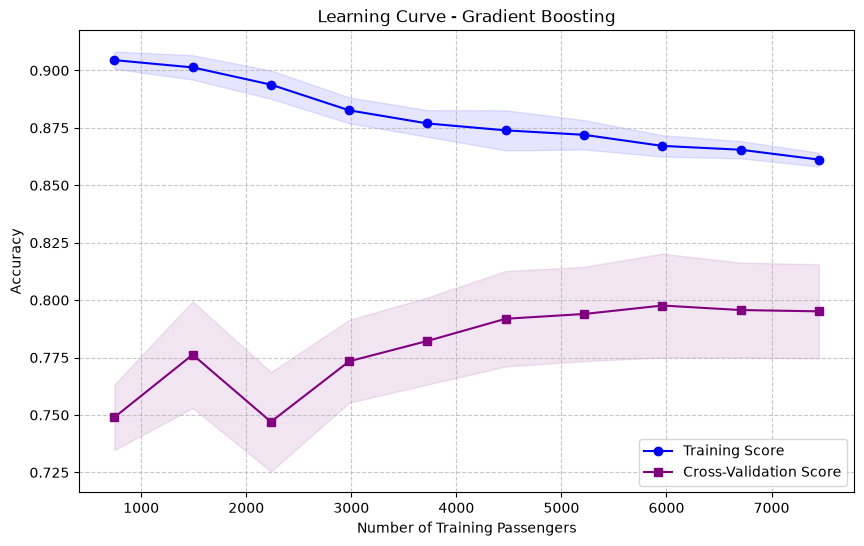

In [66]:
# Extract the best model found by GridSearchCV

best_model = search.best_estimator_

# Calculate scores for different dataset sizes (from 10% to 100%)

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model, 
    X=x, 
    y=y, 
    cv=7, 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

# Calculate means and standard deviations

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plotting the learning curve

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label="Training Score", color="blue", marker="o")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color="blue", alpha=0.1)
plt.plot(train_sizes, test_mean, label="Cross-Validation Score", color="purple", marker="s")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color="purple", alpha=0.1)

plt.title("Learning Curve - Gradient Boosting")
plt.xlabel("Number of Training Passengers")
plt.ylabel("Accuracy")
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

C:\Users\Pc\AppData\Local\Temp\ipykernel_10720\3460093692.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Features', data=df_importances, palette='viridis')


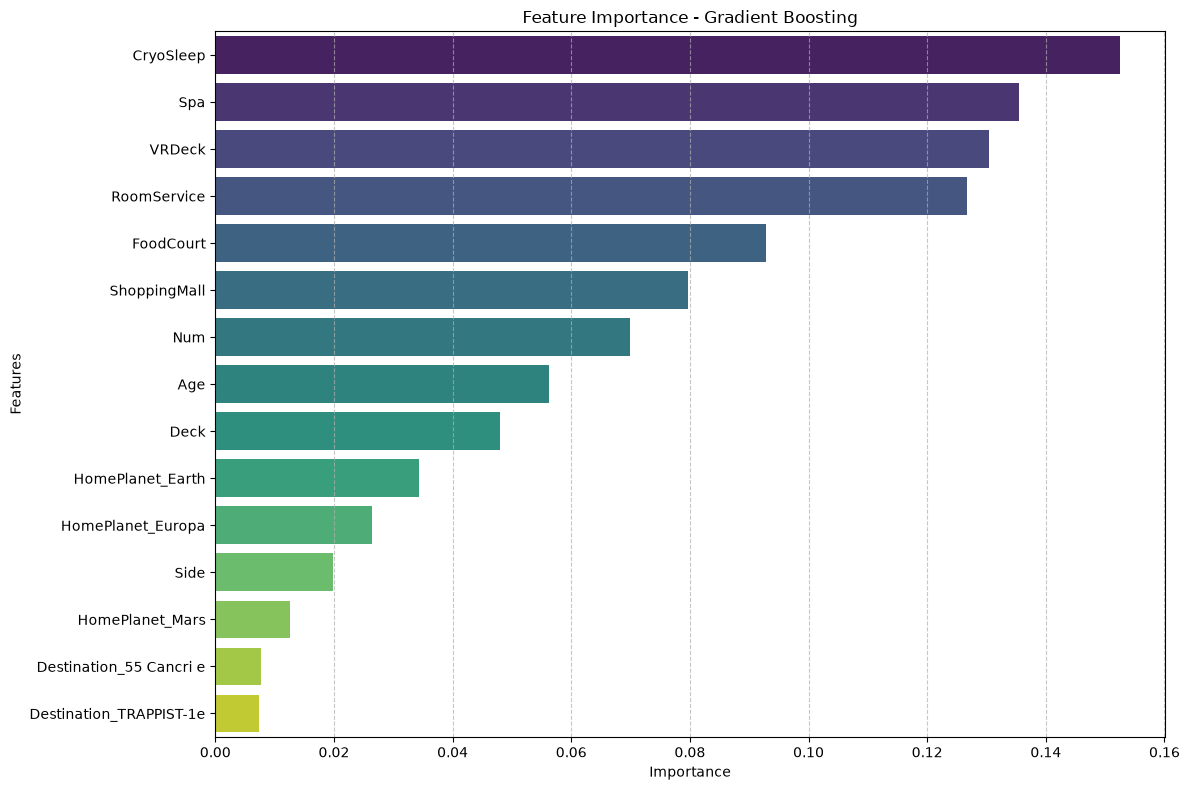

In [67]:
# Extraction of the importance of each features

importances = best_model.feature_importances_
noms_variables = x.columns

# Creation of DAtaframe to make sorting easier

df_importances = pd.DataFrame({'Features': noms_variables, 'Importance': importances})
df_importances = df_importances.sort_values(by='Importance', ascending=False)

# Plotting the feature importances

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Features', data=df_importances, palette='viridis')
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()